# Phase 2.3 — Intra-Subsystem Temperature Correlations

In [1]:
import sys, os
from pathlib import Path

# Add project root to sys.path so we can import from src/
PROJECT_ROOT = Path("D:/Personal Projects/Enbridge Case Compettion")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.load_data import load_farm_training_data
from src.features.thermal_config import (
    get_all_thermal_sensors,
    get_sensors,
    THERMAL_SUBSYSTEMS,
    SUBSYSTEM_SENSORS,
)

# Plotting defaults
sns.set_style("whitegrid")
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 13,
    "axes.labelsize": 10,
    "font.size": 9,
})

FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------------------------
# Load feature descriptions for human-readable sensor labels
# ---------------------------------------------------------------------------
DATA_ROOT = PROJECT_ROOT / "data" / "raw" / "CARE_To_Compare"

def load_feature_descriptions(farm_letter: str) -> dict[str, str]:
    """Return {sensor_XX_avg: short_description} mapping for a farm."""
    path = DATA_ROOT / f"Wind Farm {farm_letter}" / "feature_description.csv"
    fd = pd.read_csv(path, sep=";")
    mapping = {}
    for _, row in fd.iterrows():
        base_name = row["sensor_name"]
        desc = str(row["description"]).strip()
        # Truncate long descriptions to 30 chars
        if len(desc) > 30:
            desc = desc[:28] + ".."
        # Map all _avg variants
        stat_types = str(row["statistics_type"]).split(",")
        if "average" in [s.strip() for s in stat_types]:
            col_name = f"{base_name}_avg"
            mapping[col_name] = desc
    return mapping

desc_a = load_feature_descriptions("A")
desc_b = load_feature_descriptions("B")
desc_c = load_feature_descriptions("C")

def get_label(sensor_col: str, desc_map: dict) -> str:
    """Get human-readable label for a sensor column, with fallback."""
    return desc_map.get(sensor_col, sensor_col)

print(f"Project root: {PROJECT_ROOT}")
print(f"Loaded descriptions: Farm A={len(desc_a)}, Farm B={len(desc_b)}, Farm C={len(desc_c)}")

Project root: D:\Personal Projects\Enbridge Case Compettion
Loaded descriptions: Farm A=54, Farm B=63, Farm C=238


In [2]:
# Load training data — sample to 50K rows per farm for speed
MAX_ROWS = 50_000

print("Loading Farm A training data...")
df_a = load_farm_training_data("A")
if len(df_a) > MAX_ROWS:
    df_a = df_a.sample(n=MAX_ROWS, random_state=42)
print(f"  Farm A: {df_a.shape[0]:,} rows x {df_a.shape[1]} cols")

print("Loading Farm B training data...")
df_b = load_farm_training_data("B")
if len(df_b) > MAX_ROWS:
    df_b = df_b.sample(n=MAX_ROWS, random_state=42)
print(f"  Farm B: {df_b.shape[0]:,} rows x {df_b.shape[1]} cols")

print("Loading Farm C training data (thermal columns only)...")
thermal_c_cols = get_all_thermal_sensors("farm_c")
df_c = load_farm_training_data("C")[thermal_c_cols]
if len(df_c) > MAX_ROWS:
    df_c = df_c.sample(n=MAX_ROWS, random_state=42)
print(f"  Farm C: {df_c.shape[0]:,} rows x {df_c.shape[1]} cols (thermal only)")

farm_data = {"A": df_a, "B": df_b, "C": df_c}
farm_keys = {"A": "farm_a", "B": "farm_b", "C": "farm_c"}
farm_descs = {"A": desc_a, "B": desc_b, "C": desc_c}

print("\nAll farms loaded and sampled.")

Loading Farm A training data...
  Farm A: 50,000 rows x 86 cols
Loading Farm B training data...


  Farm B: 50,000 rows x 257 cols
Loading Farm C training data (thermal columns only)...


  Farm C: 50,000 rows x 58 cols (thermal only)

All farms loaded and sampled.


## Why Correlation Matters

Temperature sensors within the same thermal subsystem (e.g., gearbox bearings and oil) should be **highly correlated** during normal operation — they're measuring related components that heat up and cool down together.

**What high intra-subsystem correlation tells us:**
- Sensors are correctly grouped — they genuinely track the same physical process.
- Normal Behavior Models (Phase 3) can leverage these relationships: if one sensor deviates while others don't, that's a strong anomaly signal.

**What correlation breakdown during anomalies tells us:**
- When a specific component starts degrading, its temperature drifts away from correlated sensors.
- A gearbox bearing overheating while gearbox oil stays normal = localized fault.
- This is the core principle behind residual-based anomaly detection.

**What we're looking for here:**
- **Bright blocks on the diagonal** — sensors within subsystems moving together (r > 0.8).
- **Weaker off-diagonal blocks** — different subsystems operating somewhat independently.
- Any surprisingly low intra-subsystem correlations may indicate sensor issues or suggest splitting the subsystem.

In [3]:
def plot_subsystem_heatmaps(farm_letter: str, max_sensors_per_sub: int | None = None):
    """Plot intra-subsystem correlation heatmaps for a single farm.
    
    Returns the matplotlib figure and a dict of correlation matrices.
    """
    fk = farm_keys[farm_letter]
    df = farm_data[farm_letter]
    dm = farm_descs[farm_letter]
    
    # Collect subsystems that have 2+ sensors present in the data
    plot_subs = []
    for sub_key, sub_info in THERMAL_SUBSYSTEMS.items():
        sensors = get_sensors(fk, sub_key)
        present = [s for s in sensors if s in df.columns]
        if len(present) >= 2:
            if max_sensors_per_sub and len(present) > max_sensors_per_sub:
                # Pick a spread: first, last, and evenly spaced in between
                indices = np.linspace(0, len(present) - 1, max_sensors_per_sub, dtype=int)
                present = [present[i] for i in indices]
            plot_subs.append((sub_key, sub_info["name"], present))
    
    n_subs = len(plot_subs)
    if n_subs == 0:
        print(f"Farm {farm_letter}: no subsystems with 2+ sensors, skipping.")
        return None, {}
    
    # Determine grid layout — aim for roughly 2 columns
    ncols = min(2, n_subs)
    nrows = (n_subs + ncols - 1) // ncols
    
    # Calculate figure size proportional to content
    max_sensors_in_sub = max(len(s) for _, _, s in plot_subs)
    cell_size = 0.8  # inches per sensor in heatmap
    subplot_w = max(4, max_sensors_in_sub * cell_size + 2)
    subplot_h = max(3.5, max_sensors_in_sub * cell_size + 1.5)
    fig_w = subplot_w * ncols + 1
    fig_h = subplot_h * nrows + 1.5
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(fig_w, fig_h),
                              constrained_layout=True, squeeze=False)
    
    corr_matrices = {}
    
    for idx, (sub_key, sub_name, sensors) in enumerate(plot_subs):
        row, col = divmod(idx, ncols)
        ax = axes[row][col]
        
        # Compute correlation
        corr = df[sensors].corr()
        corr_matrices[sub_key] = corr
        
        # Human-readable labels
        labels = [get_label(s, dm) for s in sensors]
        
        # Annotate if small enough (<=8 sensors)
        do_annot = len(sensors) <= 8
        fmt = ".2f" if do_annot else ""
        annot_size = max(7, 11 - len(sensors))
        
        sns.heatmap(corr, ax=ax, annot=do_annot, fmt=fmt,
                    cmap="RdYlBu_r", center=0, vmin=-1, vmax=1,
                    xticklabels=labels, yticklabels=labels,
                    square=True, linewidths=0.5, linecolor="white",
                    cbar_kws={"shrink": 0.8, "label": "Pearson r"},
                    annot_kws={"size": annot_size})
        
        ax.set_title(f"{sub_name} ({len(sensors)} sensors)", fontweight="bold", fontsize=11)
        ax.tick_params(axis="x", rotation=45, labelsize=8)
        ax.tick_params(axis="y", rotation=0, labelsize=8)
    
    # Hide unused subplots
    for idx in range(n_subs, nrows * ncols):
        row, col = divmod(idx, ncols)
        axes[row][col].set_visible(False)
    
    fig.suptitle(f"Farm {farm_letter} — Intra-Subsystem Temperature Correlations",
                 fontsize=14, fontweight="bold")
    
    return fig, corr_matrices

print("Plotting helper defined.")

Plotting helper defined.


## Farm A Correlations

Farm A has 19 thermal sensors across 6 subsystems. Most subsystems have 2-5 sensors — small enough for fully annotated heatmaps.

Saved: D:\Personal Projects\Enbridge Case Compettion\outputs\figures\corr_intra_subsystem_farm_a.png


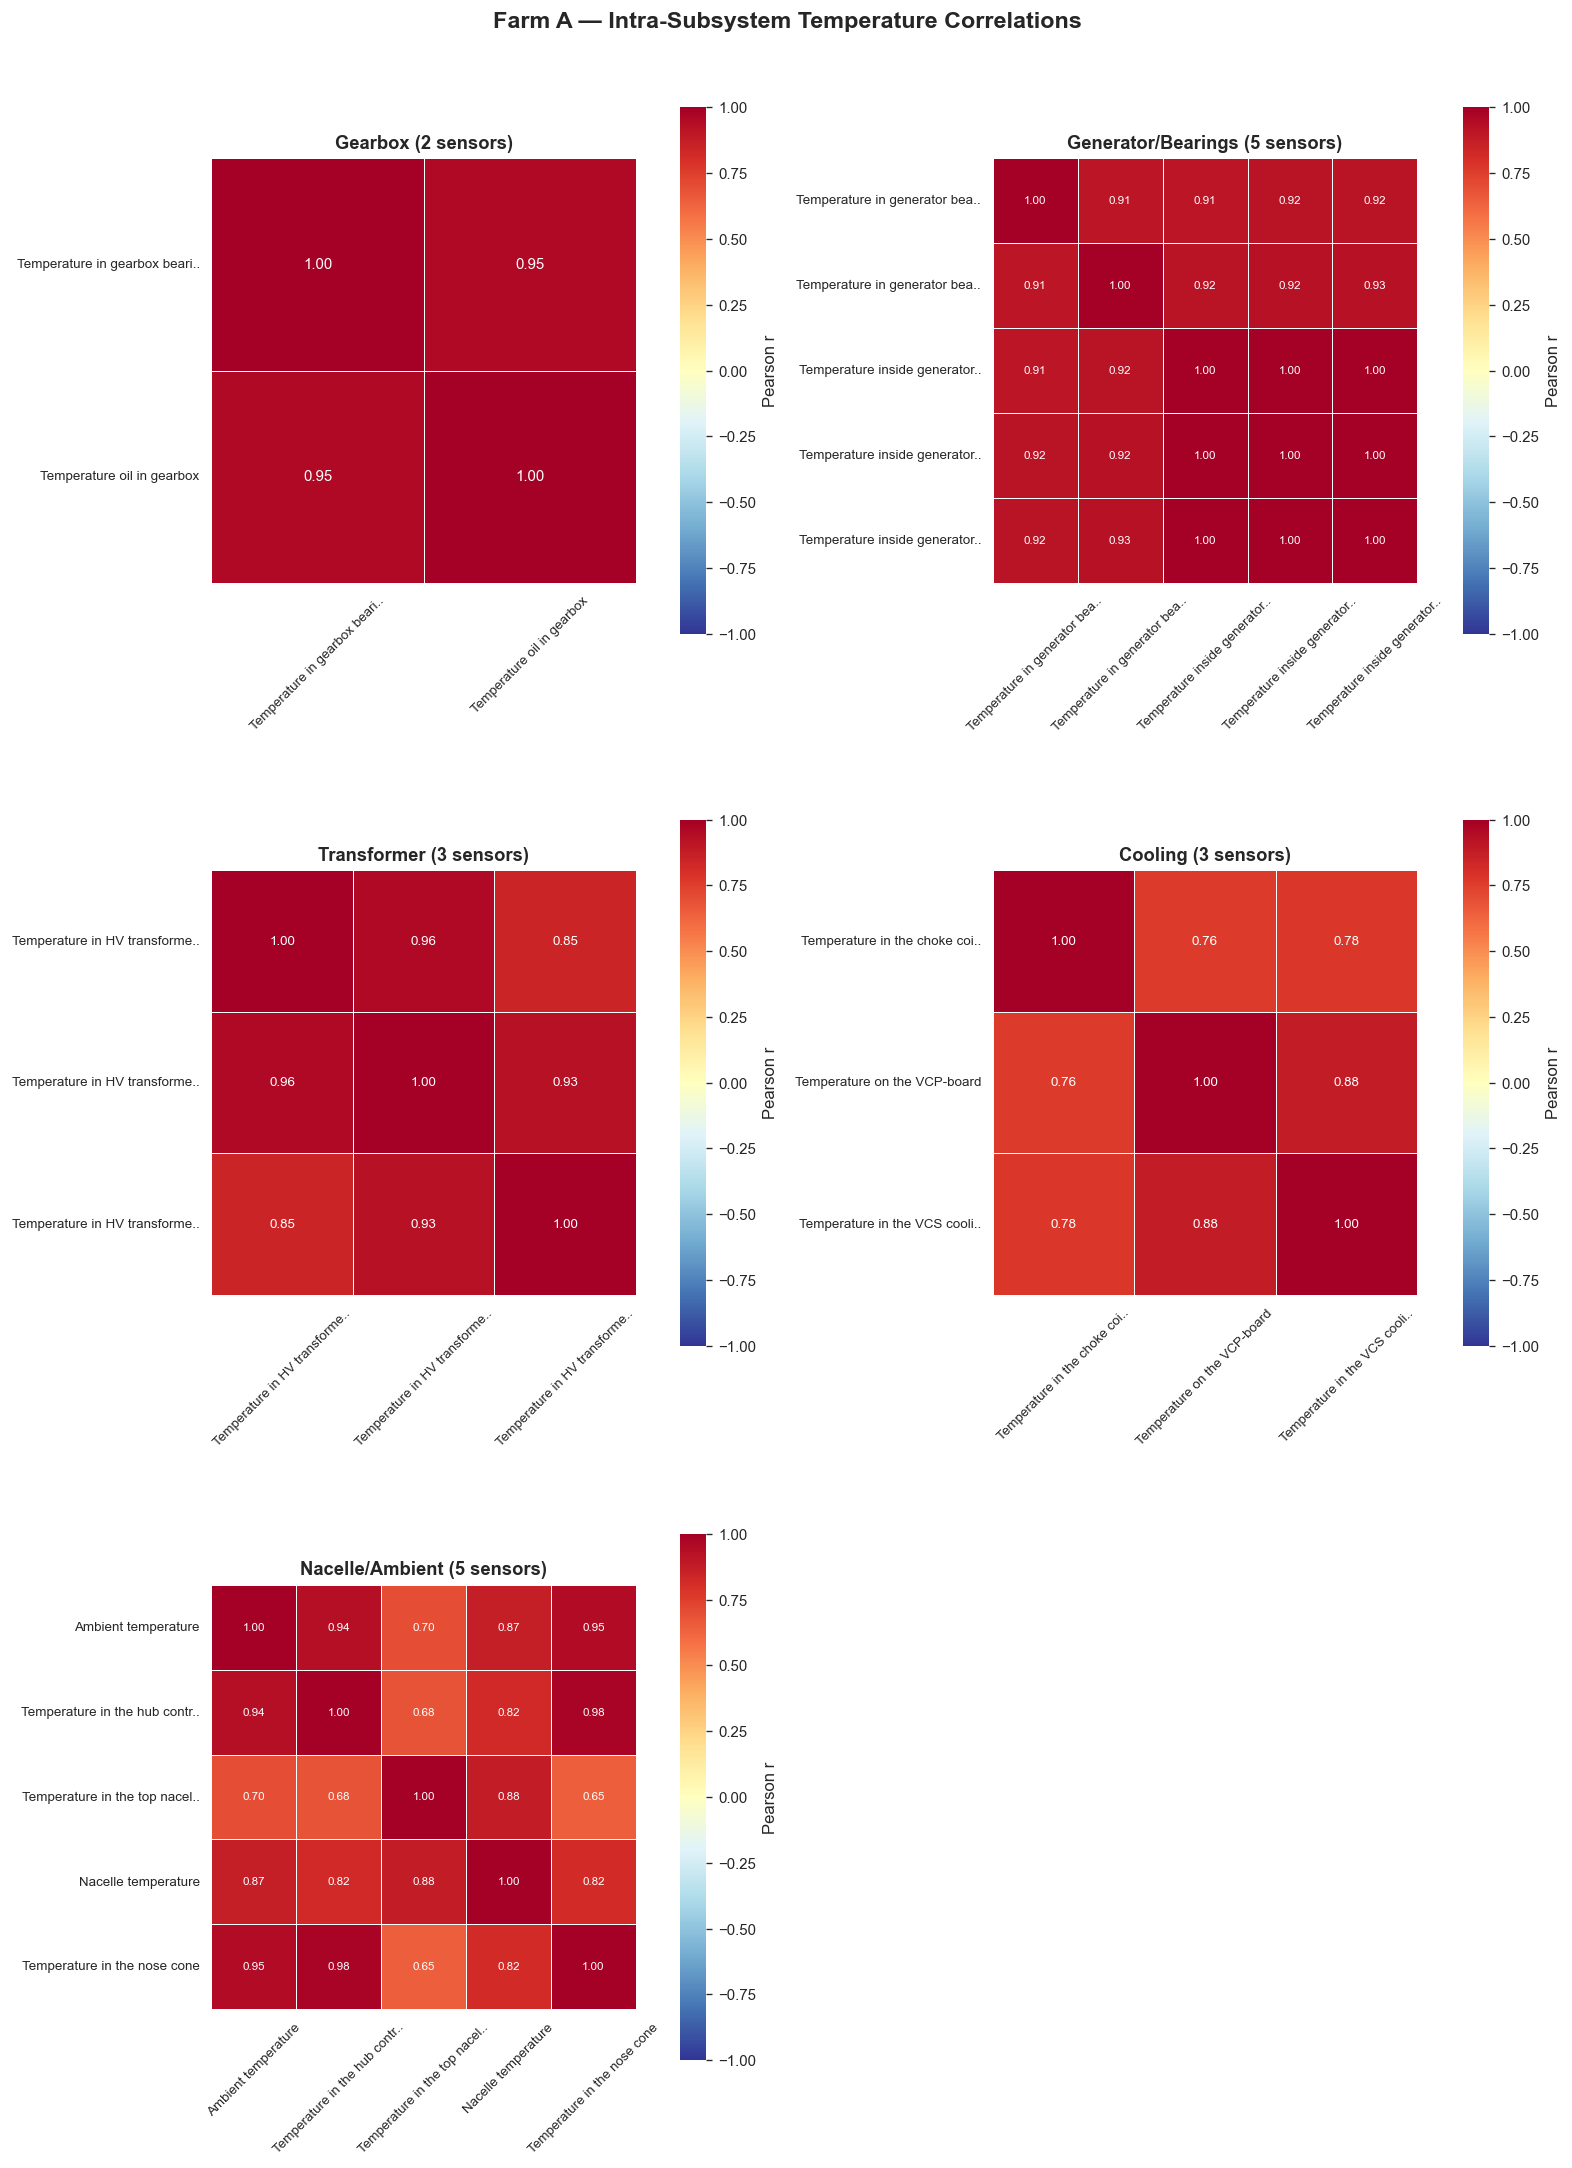


Farm A — Intra-subsystem correlation summary:
-------------------------------------------------------
  Gearbox                    mean r=0.955  min r=0.955  max r=0.955
  Generator/Bearings         mean r=0.942  min r=0.911  max r=0.998
  Transformer                mean r=0.913  min r=0.850  max r=0.960
  Cooling                    mean r=0.807  min r=0.759  max r=0.883
  Nacelle/Ambient            mean r=0.829  min r=0.646  max r=0.979


In [4]:
fig_a, corr_a = plot_subsystem_heatmaps("A")
fig_a.savefig(FIGURES_DIR / "corr_intra_subsystem_farm_a.png", bbox_inches="tight", dpi=150)
print(f"Saved: {FIGURES_DIR / 'corr_intra_subsystem_farm_a.png'}")
plt.show()

# Print summary stats for each subsystem
print("\nFarm A — Intra-subsystem correlation summary:")
print("-" * 55)
for sub_key, corr_mat in corr_a.items():
    sub_name = THERMAL_SUBSYSTEMS[sub_key]["name"]
    # Get off-diagonal values
    mask = ~np.eye(corr_mat.shape[0], dtype=bool)
    off_diag = corr_mat.values[mask]
    print(f"  {sub_name:25s}  mean r={off_diag.mean():.3f}  min r={off_diag.min():.3f}  max r={off_diag.max():.3f}")

## Farm B Correlations

Farm B has 22 thermal sensors across 4 active subsystems (no Hydraulic or Cooling sensors mapped). The Transformer subsystem has 9 sensors — the largest group.

Saved: D:\Personal Projects\Enbridge Case Compettion\outputs\figures\corr_intra_subsystem_farm_b.png


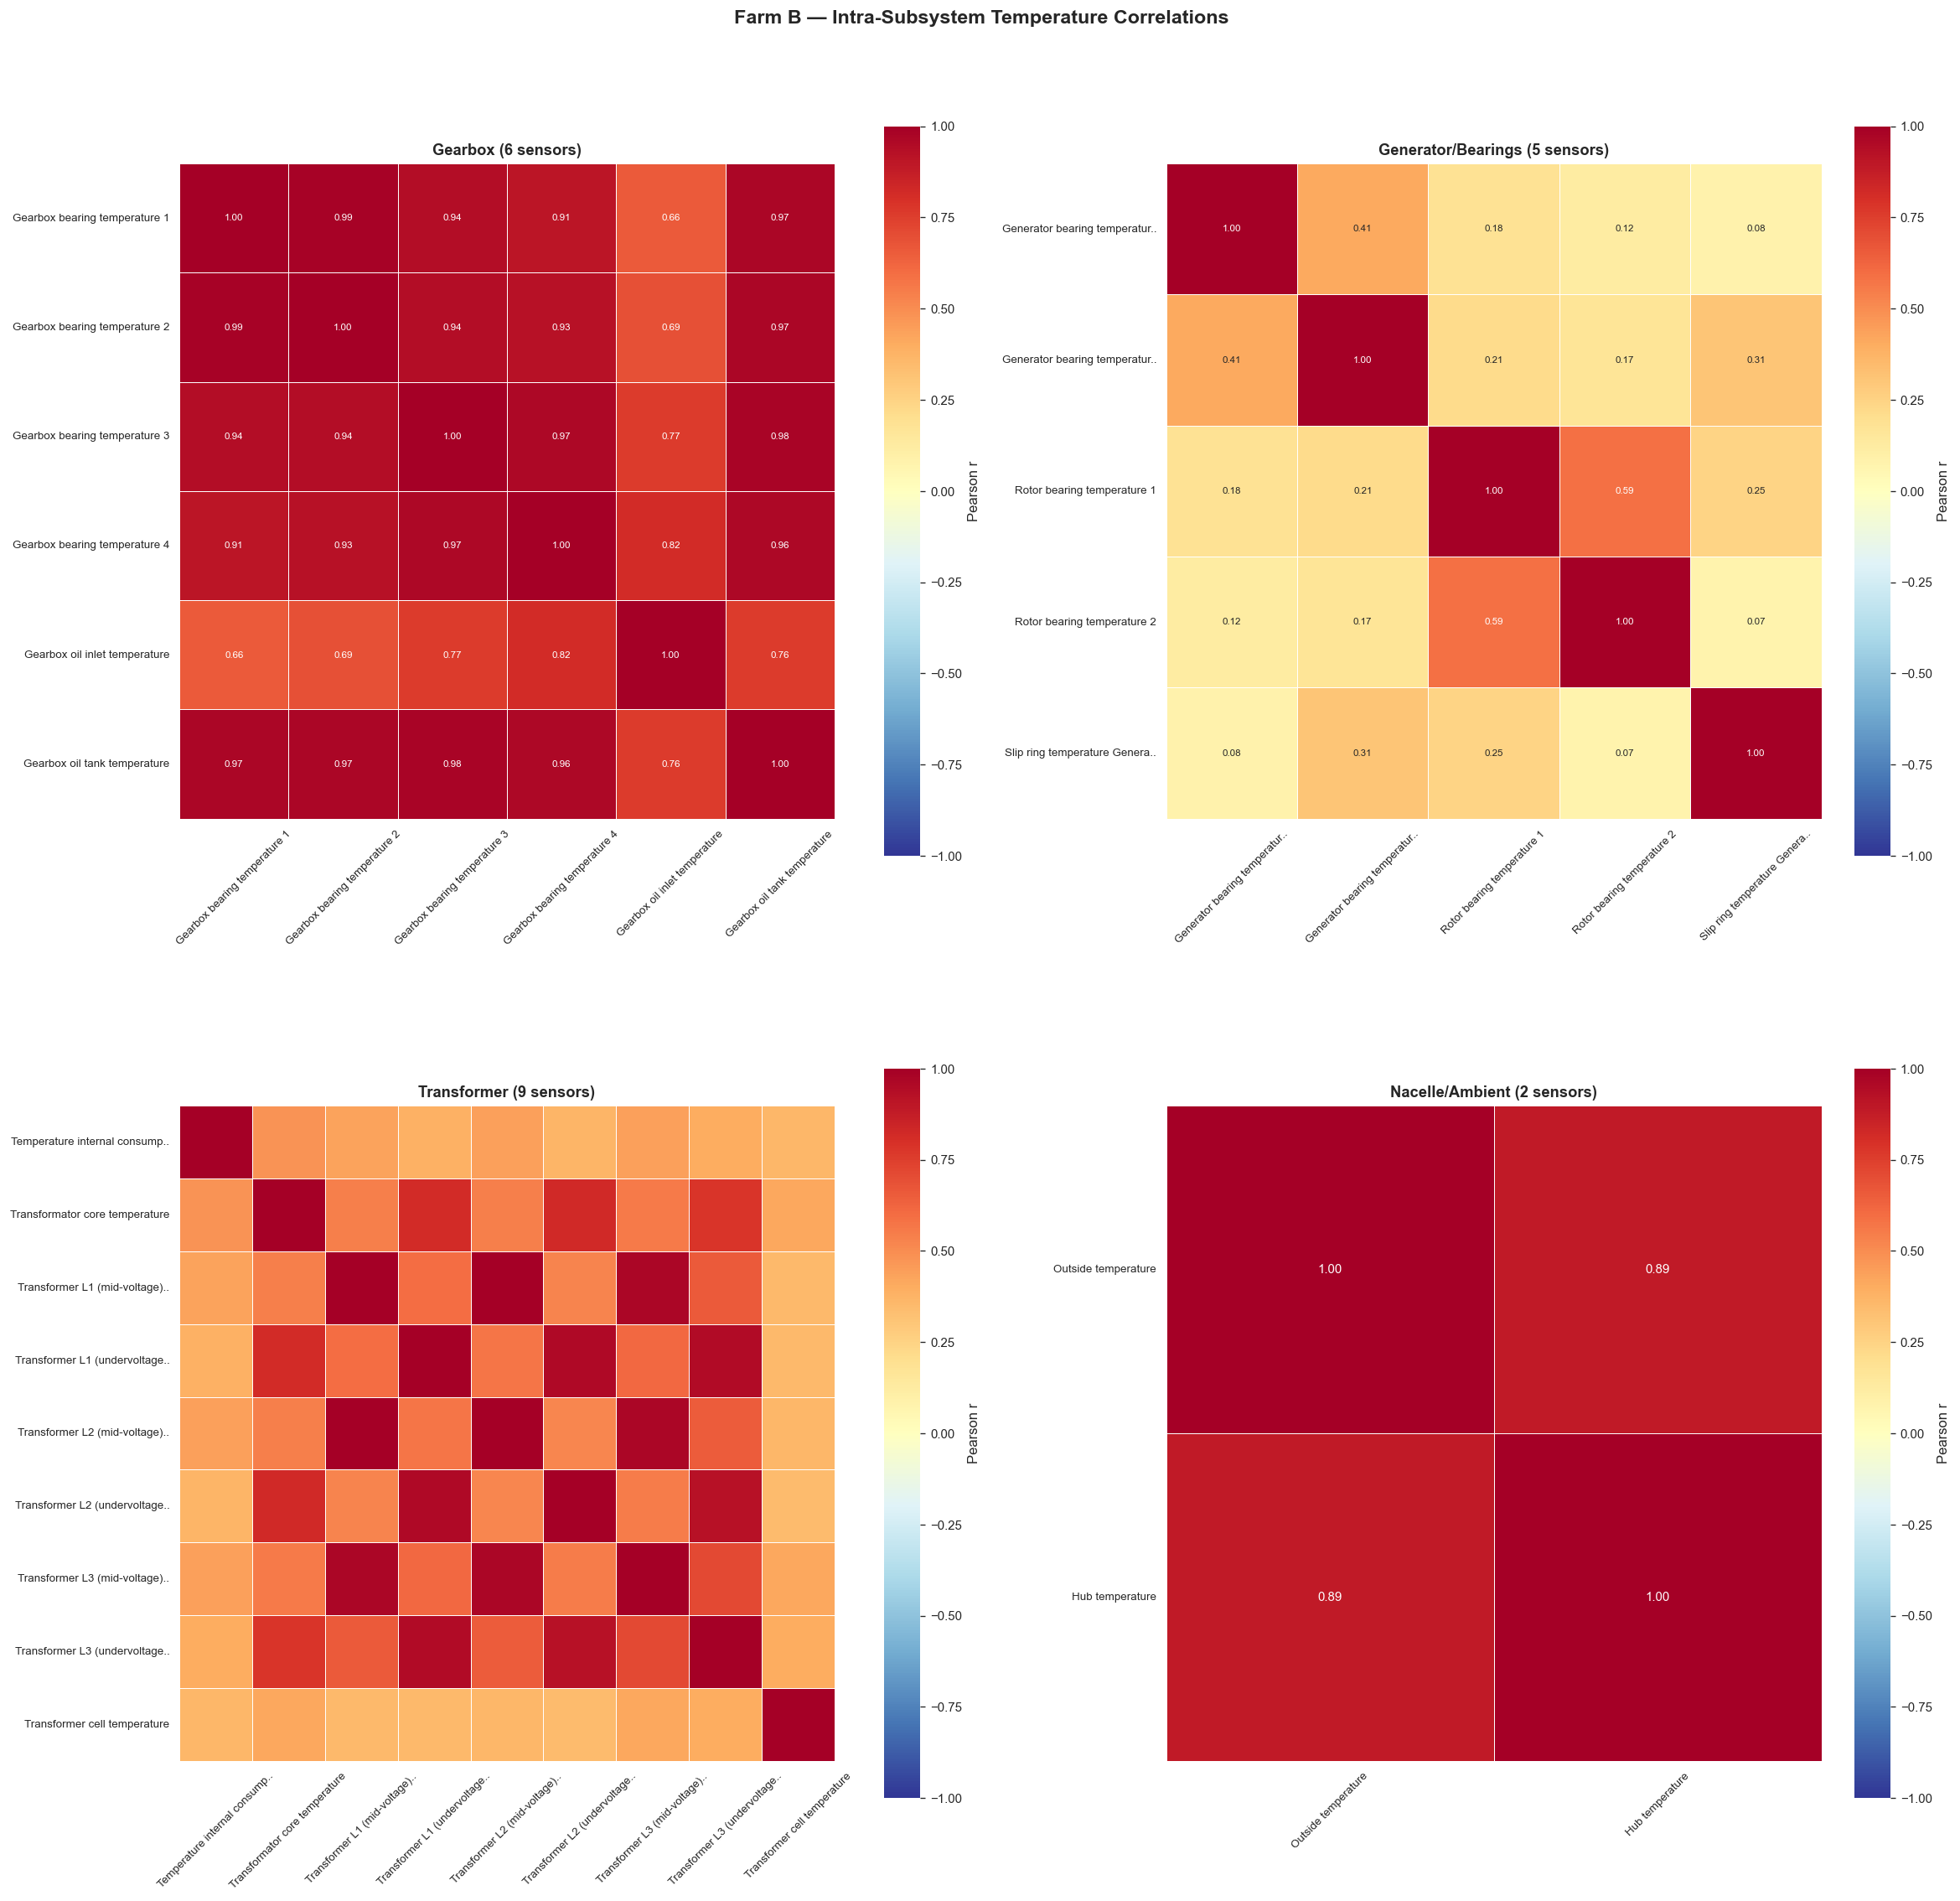


Farm B — Intra-subsystem correlation summary:
-------------------------------------------------------
  Gearbox                    mean r=0.885  min r=0.662  max r=0.992
  Generator/Bearings         mean r=0.239  min r=0.073  max r=0.587
  Transformer                mean r=0.590  min r=0.346  max r=0.994
  Nacelle/Ambient            mean r=0.889  min r=0.889  max r=0.889


In [5]:
fig_b, corr_b = plot_subsystem_heatmaps("B")
fig_b.savefig(FIGURES_DIR / "corr_intra_subsystem_farm_b.png", bbox_inches="tight", dpi=150)
print(f"Saved: {FIGURES_DIR / 'corr_intra_subsystem_farm_b.png'}")
plt.show()

print("\nFarm B — Intra-subsystem correlation summary:")
print("-" * 55)
for sub_key, corr_mat in corr_b.items():
    sub_name = THERMAL_SUBSYSTEMS[sub_key]["name"]
    mask = ~np.eye(corr_mat.shape[0], dtype=bool)
    off_diag = corr_mat.values[mask]
    print(f"  {sub_name:25s}  mean r={off_diag.mean():.3f}  min r={off_diag.min():.3f}  max r={off_diag.max():.3f}")

## Farm C Correlations

Farm C has 58 thermal sensors — the most instrumented farm. The Gearbox subsystem alone has 20 sensors, and Generator/Bearings has 19. To keep heatmaps readable, we select 5-6 representative sensors per subsystem (evenly spread across the sensor list).

Saved: D:\Personal Projects\Enbridge Case Compettion\outputs\figures\corr_intra_subsystem_farm_c.png


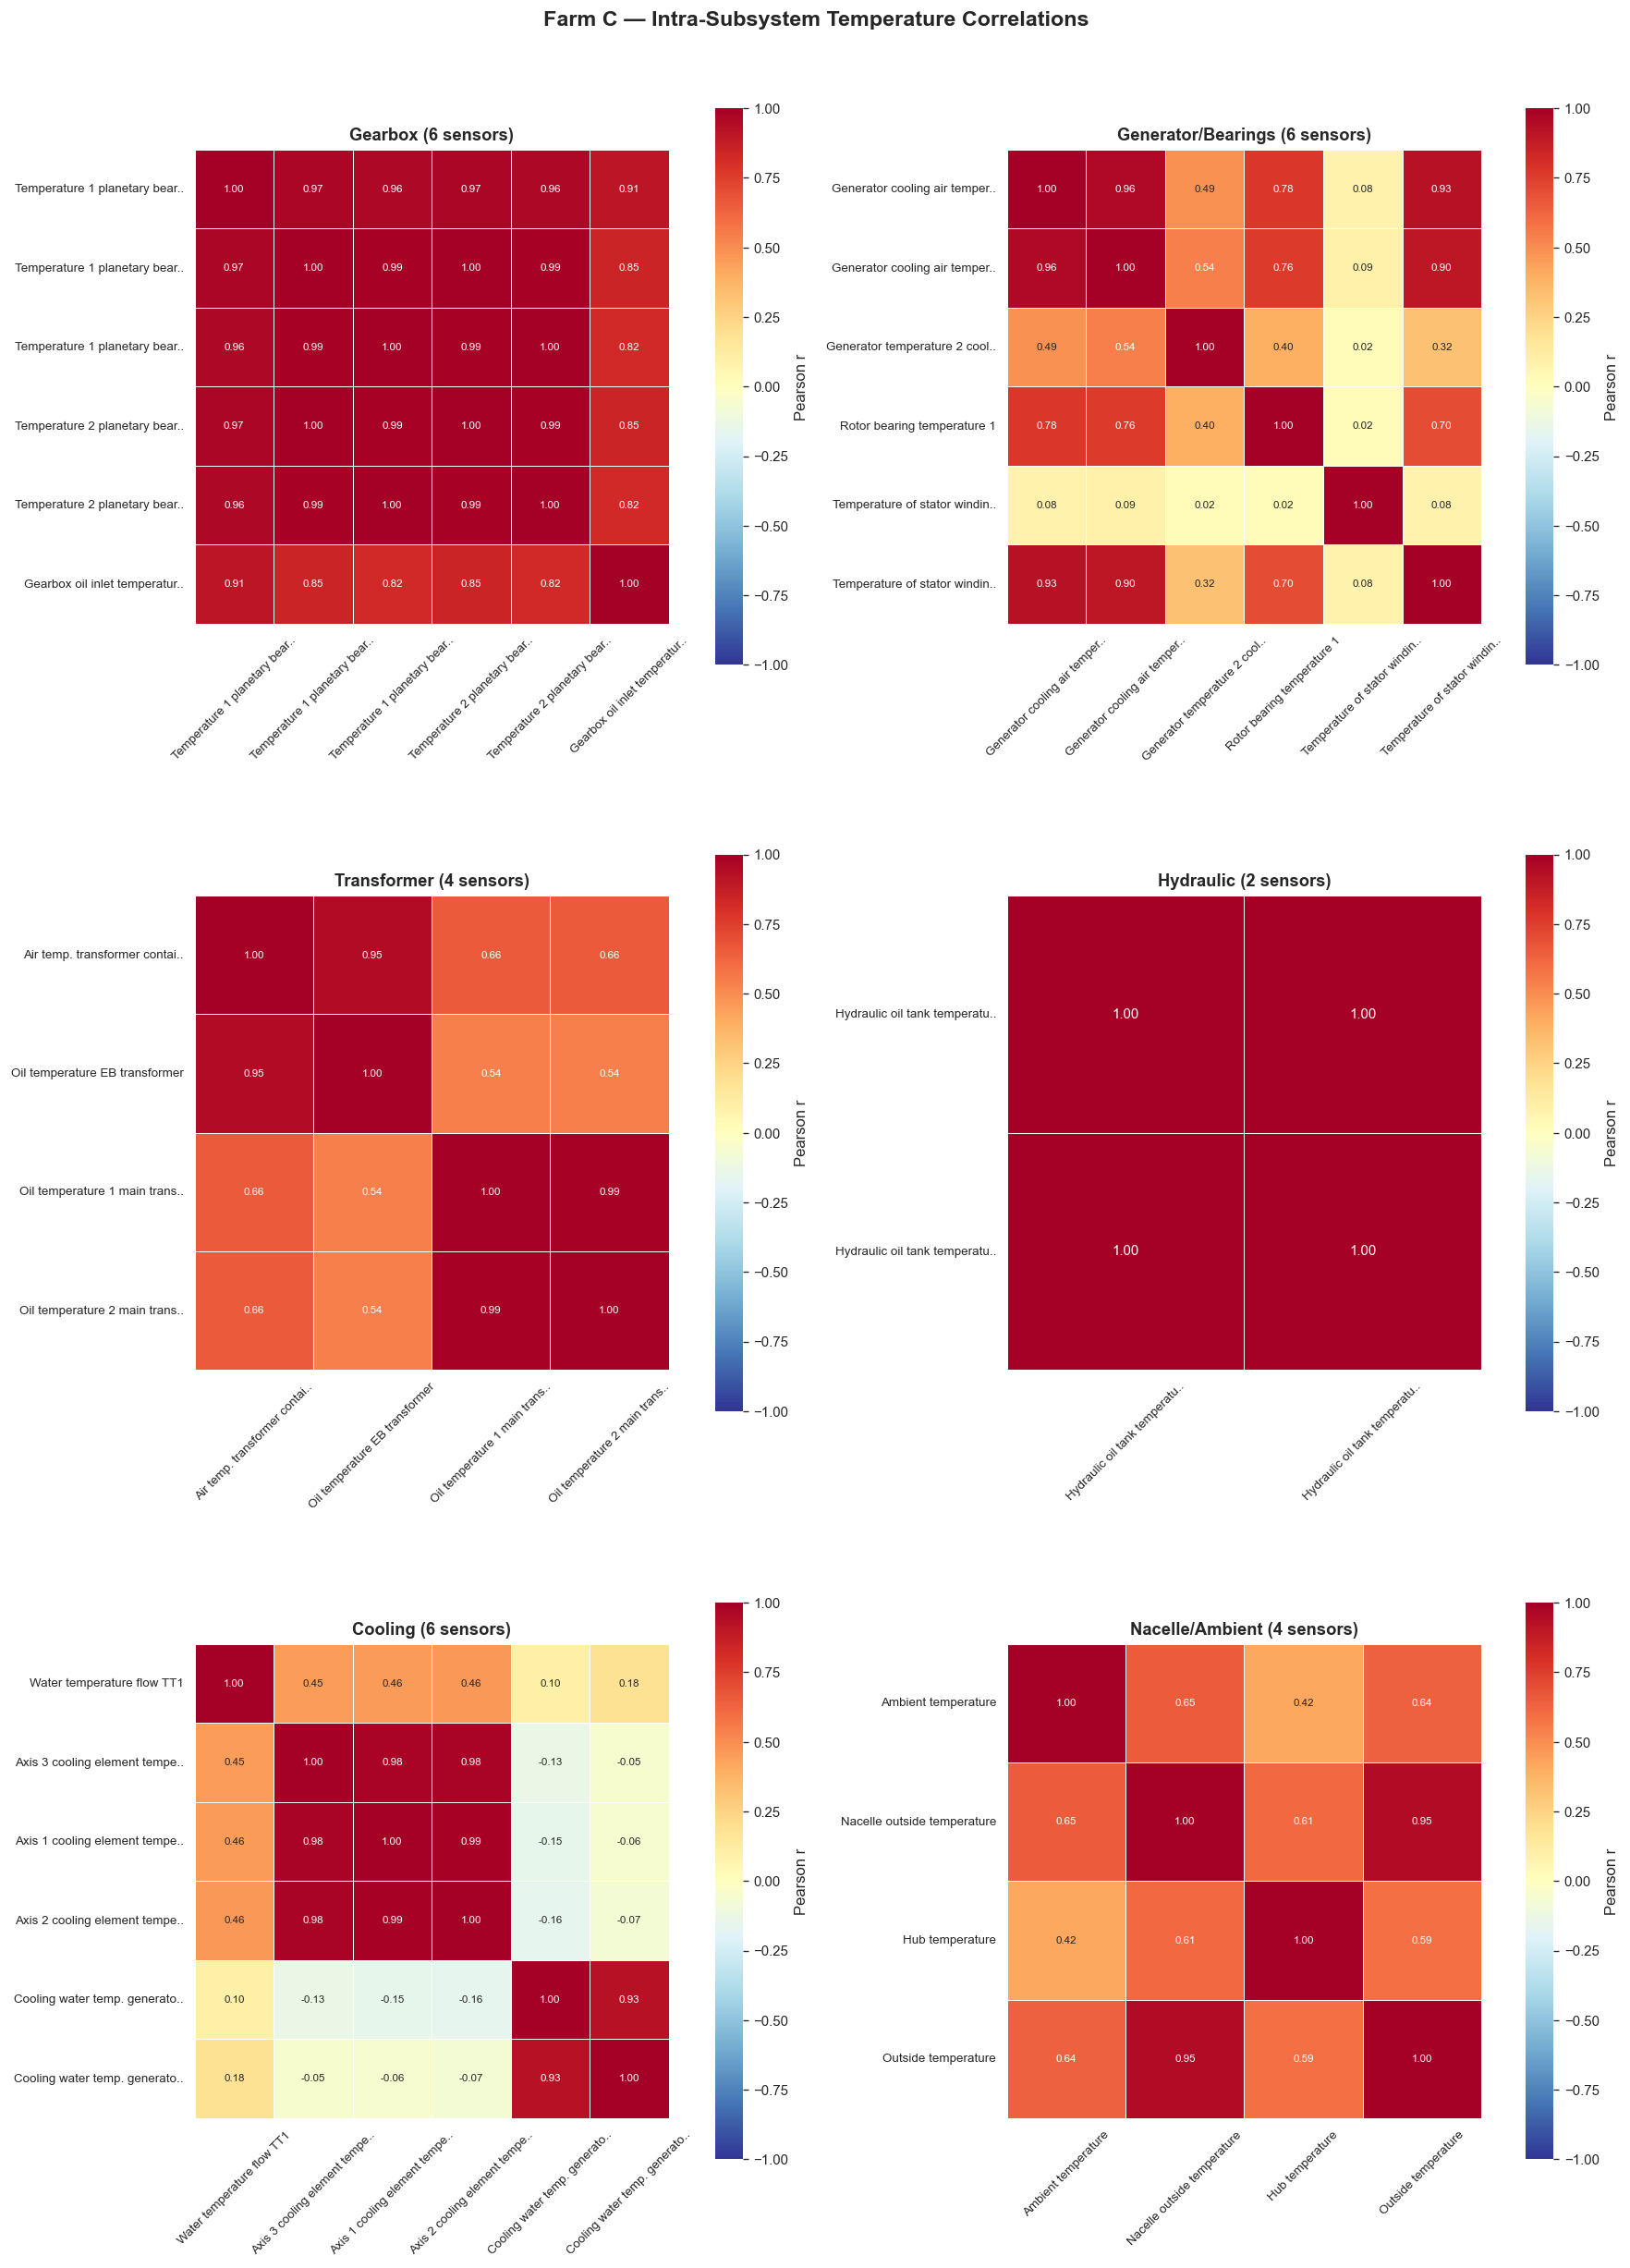


Farm C — Intra-subsystem correlation summary (ALL sensors):
-------------------------------------------------------
  Gearbox                    n=20  mean r=0.788  min r=0.012  max r=1.000
  Generator/Bearings         n=19  mean r=0.486  min r=-0.049  max r=1.000
  Transformer                n= 4  mean r=0.723  min r=0.541  max r=0.989
  Hydraulic                  n= 2  mean r=1.000  min r=1.000  max r=1.000
  Cooling                    n= 9  mean r=0.324  min r=-0.160  max r=0.999
  Nacelle/Ambient            n= 4  mean r=0.643  min r=0.417  max r=0.948


In [6]:
fig_c, corr_c = plot_subsystem_heatmaps("C", max_sensors_per_sub=6)
fig_c.savefig(FIGURES_DIR / "corr_intra_subsystem_farm_c.png", bbox_inches="tight", dpi=150)
print(f"Saved: {FIGURES_DIR / 'corr_intra_subsystem_farm_c.png'}")
plt.show()

# Full correlation summary (all sensors, not just the plotted subset)
print("\nFarm C — Intra-subsystem correlation summary (ALL sensors):")
print("-" * 55)
for sub_key, sub_info in THERMAL_SUBSYSTEMS.items():
    sensors = get_sensors("farm_c", sub_key)
    present = [s for s in sensors if s in df_c.columns]
    if len(present) < 2:
        continue
    corr_full = df_c[present].corr()
    mask = ~np.eye(corr_full.shape[0], dtype=bool)
    off_diag = corr_full.values[mask]
    print(f"  {sub_info['name']:25s}  n={len(present):2d}  mean r={off_diag.mean():.3f}  min r={off_diag.min():.3f}  max r={off_diag.max():.3f}")

## Cross-Subsystem Correlations

Are the 6 subsystems truly independent of each other, or do some track together?

Using Farm A (simplest, 19 sensors) we compute the **full correlation matrix** across ALL thermal sensors, grouped by subsystem. If our groupings are good, we should see:

- **Bright blocks along the diagonal** — sensors within the same subsystem are highly correlated.
- **Darker off-diagonal regions** — sensors in different subsystems are less correlated.
- Any unexpectedly high cross-subsystem correlation may suggest the subsystems aren't fully independent (which is expected to some degree — ambient temperature affects everything).

Saved: D:\Personal Projects\Enbridge Case Compettion\outputs\figures\corr_cross_subsystem_farm_a.png


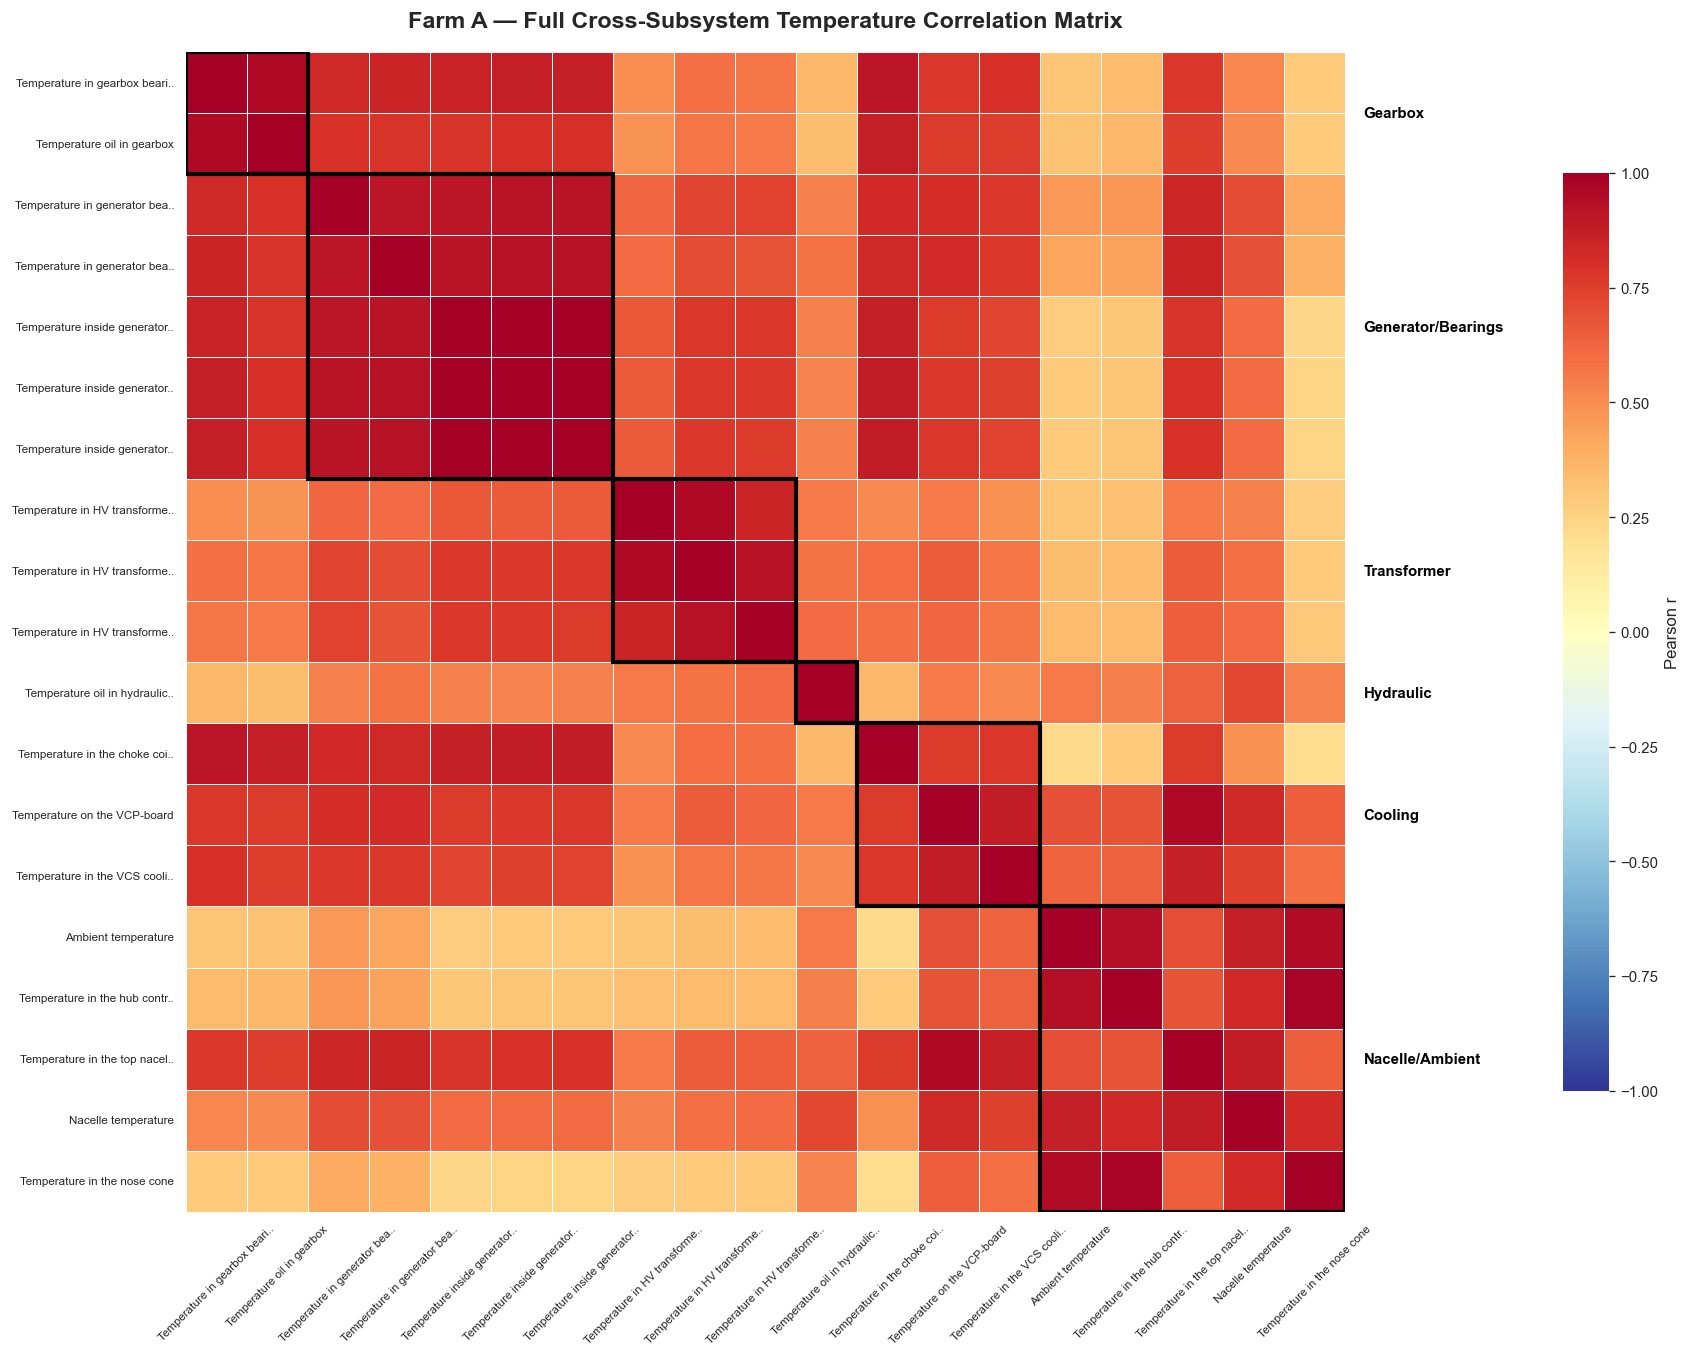


Farm A — Average correlation BETWEEN subsystems:
-----------------------------------------------------------------
  Gearbox                   <-> Generator/Bearings         avg r = 0.823
  Gearbox                   <-> Transformer                avg r = 0.544
  Gearbox                   <-> Hydraulic                  avg r = 0.354
  Gearbox                   <-> Cooling                    avg r = 0.813
  Gearbox                   <-> Nacelle/Ambient            avg r = 0.446
  Generator/Bearings        <-> Transformer                avg r = 0.715
  Generator/Bearings        <-> Hydraulic                  avg r = 0.543
  Generator/Bearings        <-> Cooling                    avg r = 0.798
  Generator/Bearings        <-> Nacelle/Ambient            avg r = 0.494
  Transformer               <-> Hydraulic                  avg r = 0.581
  Transformer               <-> Cooling                    avg r = 0.573
  Transformer               <-> Nacelle/Ambient            avg r = 0.430
  Hydrau

In [7]:
# Build ordered sensor list grouped by subsystem for Farm A
ordered_sensors_a = []
subsystem_labels_a = []  # subsystem name for each sensor
subsystem_boundaries_a = []  # (start_idx, end_idx, name)

for sub_key, sub_info in THERMAL_SUBSYSTEMS.items():
    sensors = get_sensors("farm_a", sub_key)
    present = [s for s in sensors if s in df_a.columns]
    if not present:
        continue
    start = len(ordered_sensors_a)
    ordered_sensors_a.extend(present)
    subsystem_labels_a.extend([sub_info["name"]] * len(present))
    subsystem_boundaries_a.append((start, start + len(present), sub_info["name"]))

# Compute full correlation matrix
corr_full_a = df_a[ordered_sensors_a].corr()

# Human-readable labels
full_labels_a = [get_label(s, desc_a) for s in ordered_sensors_a]

# Plot
fig, ax = plt.subplots(figsize=(14, 12), constrained_layout=True)

sns.heatmap(corr_full_a, ax=ax,
            cmap="RdYlBu_r", center=0, vmin=-1, vmax=1,
            xticklabels=full_labels_a, yticklabels=full_labels_a,
            square=True, linewidths=0.3, linecolor="white",
            cbar_kws={"shrink": 0.7, "label": "Pearson r"})

# Draw black rectangles around subsystem blocks
for start, end, name in subsystem_boundaries_a:
    size = end - start
    rect = plt.Rectangle((start, start), size, size,
                          fill=False, edgecolor="black", linewidth=2.5)
    ax.add_patch(rect)
    # Label the block on the right side
    ax.text(len(ordered_sensors_a) + 0.3, start + size / 2, name,
            ha="left", va="center", fontsize=9, fontweight="bold",
            color="black")

ax.set_title("Farm A — Full Cross-Subsystem Temperature Correlation Matrix",
             fontsize=14, fontweight="bold", pad=15)
ax.tick_params(axis="x", rotation=45, labelsize=7)
ax.tick_params(axis="y", rotation=0, labelsize=7)

fig.savefig(FIGURES_DIR / "corr_cross_subsystem_farm_a.png", bbox_inches="tight", dpi=150)
print(f"Saved: {FIGURES_DIR / 'corr_cross_subsystem_farm_a.png'}")
plt.show()

# Print cross-subsystem average correlations
print("\nFarm A — Average correlation BETWEEN subsystems:")
print("-" * 65)
sub_names = [name for _, _, name in subsystem_boundaries_a]
for i, (s1, e1, n1) in enumerate(subsystem_boundaries_a):
    for j, (s2, e2, n2) in enumerate(subsystem_boundaries_a):
        if j <= i:
            continue
        block = corr_full_a.iloc[s1:e1, s2:e2].values
        avg_r = np.mean(block)
        print(f"  {n1:25s} <-> {n2:25s}  avg r = {avg_r:.3f}")

In [8]:
# Print summary of all saved figures from this notebook
print("=" * 60)
print("All figures saved to outputs/figures/:")
print("=" * 60)
for f in sorted(FIGURES_DIR.glob("corr_*.png")):
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name:45s} ({size_kb:.0f} KB)")

All figures saved to outputs/figures/:
  corr_cross_subsystem_farm_a.png               (164 KB)
  corr_intra_subsystem_farm_a.png               (262 KB)
  corr_intra_subsystem_farm_b.png               (312 KB)
  corr_intra_subsystem_farm_c.png               (393 KB)


## Key Observations

*(Fill in after reviewing the plots above)*

**Intra-subsystem correlations:**
- **Gearbox:** 
- **Generator/Bearings:** 
- **Transformer:** 
- **Hydraulic:** 
- **Cooling:** 
- **Nacelle/Ambient:** 

**Cross-subsystem patterns (Farm A):**
- 

**Implications for Phase 3 (Normal Behavior Models):**
- 
- 

**Subsystem grouping validation:**
- 